# Multi-Class Network Intrusion Detection System
### Preprocessing · Feature Engineering · Model Training · Export

| Class | Label | Attack Description |
|-------|-------|-------------------|
| Normal    | 0 | Legitimate background traffic |
| DDoS-TCP  | 1 | SYN flood — TCP protocol |
| PortScan  | 3 | Sequential port probing |
| Fuzzer    | 4 | Random / malformed packet injection |
| BruteForce| 5 | Repeated auth attempts (SSH / FTP / HTTP) |

**Output:** `features_final.csv` + `ids_bundle.pkl` (models + scaler + metadata)  
**Used by:** `dashboard.py`


## 0 — Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
import gc
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# ── File paths — adjust to your CSV locations ────────────────────────────────
# Each file must be a Wireshark CSV export with columns:
#   No., Time, Source, Destination, Protocol, Length, Info
#
# DDoS-TCP  : a capture containing both normal traffic and a SYN-flood period.
#             Label is assigned by IP + time-window rule below.
# DDoS-UDP  : a capture where all (or most) traffic is a UDP flood.
#             Label is assigned by Protocol == 'UDP' rule.
# DDoS-ICMP : a capture where all (or most) traffic is an ICMP flood.
#             Label is assigned by Protocol == 'ICMP' rule.
# PortScan  : a capture of port-scan traffic (all rows → label 4).
# Fuzzer    : a capture of fuzzing/malformed-packet traffic (all rows → label 5).
# BruteForce: a capture of brute-force traffic (all rows → label 6).

DDOS_TCP_CSV    = 'all_traffic.csv'# contains normal + SYN-flood
PORTSCAN_CSV    = 'Port_Scanning.csv'
FUZZER_CSV      = 'Fuzzer_Attack.csv'
BRUTEFORCE_CSV  = 'Brute Force ATTACK.csv'

OUTPUT_FEATURES = 'features_final.csv'
OUTPUT_BUNDLE   = 'ids_bundle.pkl'

# ── DDoS-TCP labeling rule (SYN flood window inside the mixed capture) ────────
DDOS_SRC     = '10.0.0.5'
DDOS_DST     = '10.0.0.3'
DDOS_T_START = 196.0
DDOS_T_END   = 235.0

# ── Class map ─────────────────────────────────────────────────────────────────
CLASS_NAMES = {
    0: 'Normal',
    1: 'DDoS',
    2: 'PortScan',
    3: 'Fuzzer',
    4: 'BruteForce',
}

CLASS_COLORS = {
    0: '#639922',   # green   — safe
    1: '#E24B4A',   # red     — DDoS-TCP
    2: '#378ADD',   # blue    — PortScan
    3: '#7F77DD',   # purple  — Fuzzer
    4: '#D4537E',   # pink    — BruteForce
}

CLASS_FILL = {
    0: '#EAF3DE',
    1: '#FCEBEB',
    2: '#E6F1FB',
    3: '#EEEDFE',
    4: '#FBEAF0',
}

# ── Protocol numeric map (mirrors Wireshark display names) ────────────────────
PROTOCOL_MAP = {
    'ICMP':     1,
    'TCP':      6,
    'UDP':      17,
    'ICMPv6':   58,
    'ARP':      2054,
    'OpenFlow': 6653,
    'DNS':      53,
    'MDNS':     5353,
    'HTTP':     80,
}

print('Configuration loaded.')
print(f'Classes: {CLASS_NAMES}')

Configuration loaded.
Classes: {0: 'Normal', 1: 'DDoS', 2: 'PortScan', 3: 'Fuzzer', 4: 'BruteForce'}


## 1 — Load & Clean

In [ ]:
def _load_and_clean(path, nrows=None):
    """
    Read a Wireshark CSV, coerce types, drop bad rows, sort by Time.
    Expected columns: No., Time, Source, Destination, Protocol, Length, Info
    """
    import numpy as np
    usecols = ['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
    dtypes = {
        'Time': np.float64,
        'Source': 'category',
        'Destination': 'category',
        'Protocol': 'category',
        'Length': np.float32,
        'Info': str
    }
    df = pd.read_csv(path, nrows=nrows, usecols=usecols, dtype=dtypes)
    print(f'  Original : {df.shape}')

    # Drop rows with no destination (malformed / non-IP summary lines)
    df = df.dropna(subset=['Destination']).reset_index(drop=True)

    df['Time']   = pd.to_numeric(df['Time'],   errors='coerce')
    df['Length'] = pd.to_numeric(df['Length'], errors='coerce').fillna(0).astype(np.int32)
    df['Info']   = df['Info'].astype(str)

    df['Protocol'] = df['Protocol'].astype('category')
    df['Source'] = df['Source'].astype('category')
    df['Destination'] = df['Destination'].astype('category')

    df = df.dropna(subset=['Time', 'Length']).reset_index(drop=True)
    df = df.sort_values('Time').reset_index(drop=True)
    print(f'  Cleaned  : {df.shape}')
    return df


In [ ]:
# ── DDoS-TCP (mixed capture — normal + SYN flood) ─────────────────────────────
print('Loading DDoS...')
df_ddos_tcp = _load_and_clean(DDOS_TCP_CSV)

df_ddos_tcp['Label'] = np.where(
    (df_ddos_tcp['Source']      == DDOS_SRC) &
    (df_ddos_tcp['Destination'] == DDOS_DST) &
    (df_ddos_tcp['Time']        >= DDOS_T_START) &
    (df_ddos_tcp['Time']        <= DDOS_T_END),
    1,   # DDoS-TCP
    0    # Normal
)

print('Label distribution:')
print(df_ddos_tcp['Label'].value_counts().rename(CLASS_NAMES))
print()
df_ddos_tcp.head(3)


Loading DDoS...
  Original : (13276818, 6)
  Cleaned  : (13276718, 6)
Label distribution:
Label
Normal    6990764
DDoS      6285954
Name: count, dtype: int64



,Time,Source,Destination,Protocol,Length,Info,Label
0,0.00000,127.0.0.1,127.0.0.1,OpenFlow,80,Type: OFPT_ECHO_REQUEST,0
1,0.00046,127.0.0.1,127.0.0.1,OpenFlow,80,Type: OFPT_ECHO_REPLY,0
2,0.00048,127.0.0.1,127.0.0.1,TCP,72,42426 > 6653 [ACK] Seq=9 Ack=9 Win=86 Len=0 ...,0


In [ ]:
# ── PortScan ──────────────────────────────────────────────────────────────────
print('Loading PortScan ...')
df_pscan = _load_and_clean(PORTSCAN_CSV,nrows= 300000)
df_pscan['Label'] = 2
print(f'Rows: {len(df_pscan):,}')
print()

# ── Fuzzer ────────────────────────────────────────────────────────────────────
print('Loading Fuzzer ...')
df_fuzzer = _load_and_clean(FUZZER_CSV)
df_fuzzer['Label'] = 3
print(f'Rows: {len(df_fuzzer):,}')
print()

# ── BruteForce ────────────────────────────────────────────────────────────────
print('Loading BruteForce ...')
df_brute = _load_and_clean(BRUTEFORCE_CSV)
df_brute['Label'] = 4
print(f'Rows: {len(df_brute):,}')


Loading PortScan ...
  Original : (300000, 6)
  Cleaned  : (299932, 6)
Rows: 299,932

Loading Fuzzer ...
  Original : (1008163, 6)
  Cleaned  : (1008163, 6)
Rows: 1,008,163

Loading BruteForce ...
  Original : (151596, 6)
  Cleaned  : (151596, 6)
Rows: 151,596


In [ ]:
df_pscan

,Time,Source,Destination,Protocol,Length,Info,Label
0,13.049552,10.0.0.18,10.0.0.1,TCP,64,44816 > 135 [SYN] Seq=0 Win=1024 Len=0 MSS=1460,2
1,13.049555,10.0.0.18,10.0.0.1,TCP,64,44816 > 1025 [SYN] Seq=0 Win=1024 Len=0 MSS=...,2
2,13.049557,10.0.0.18,10.0.0.1,TCP,64,44816 > 554 [SYN] Seq=0 Win=1024 Len=0 MSS=1460,2
3,13.049559,10.0.0.18,10.0.0.1,TCP,64,44816 > 113 [SYN] Seq=0 Win=1024 Len=0 MSS=1460,2
4,13.049560,10.0.0.18,10.0.0.1,TCP,64,44816 > 139 [SYN] Seq=0 Win=1024 Len=0 MSS=1460,2
...,...,...,...,...,...,...,...
299927,13.543239,10.0.0.18,10.0.0.1,TCP,64,[TCP Out-Of-Order] [TCP Port numbers reused] 4...,2
299928,13.543242,10.0.0.1,10.0.0.18,TCP,60,"11927 > 44816 [RST, ACK] Seq=1 Ack=1 Win=0 L...",2
299929,13.543242,10.0.0.1,10.0.0.18,TCP,60,"11927 > 44816 [RST, ACK] Seq=1 Ack=1 Win=0 L...",2
299930,13.543242,10.0.0.1,10.0.0.18,TCP,60,"11927 > 44816 [RST, ACK] Seq=1 Ack=1 Win=0 L...",2


In [ ]:
df_fuzzer

,Time,Source,Destination,Protocol,Length,Info,Label
0,0.000000,10.0.0.18,10.0.0.1,TCP,80,58590 > 80 [SYN] Seq=0 Win=42340 Len=0 MSS=1...,3
1,0.001586,10.0.0.18,10.0.0.1,TCP,80,[TCP Out-Of-Order] [TCP Port numbers reused] 5...,3
2,0.001588,10.0.0.18,10.0.0.1,TCP,80,[TCP Out-Of-Order] [TCP Port numbers reused] 5...,3
3,0.003005,10.0.0.18,10.0.0.1,TCP,80,[TCP Retransmission] [TCP Port numbers reused]...,3
4,0.003006,10.0.0.18,10.0.0.1,TCP,80,[TCP Retransmission] [TCP Port numbers reused]...,3
...,...,...,...,...,...,...,...
1008158,1151.693097,10.0.0.1,10.0.0.18,TCP,72,[TCP Dup ACK 1008158#1] 80 > 52582 [ACK] Seq...,3
1008159,1151.693100,10.0.0.1,10.0.0.18,TCP,72,[TCP Dup ACK 1008158#2] 80 > 52582 [ACK] Seq...,3
1008160,1151.693104,10.0.0.1,10.0.0.18,TCP,72,[TCP Dup ACK 1008158#3] 80 > 52582 [ACK] Seq...,3
1008161,1151.693106,10.0.0.1,10.0.0.18,TCP,72,[TCP Dup ACK 1008158#4] 80 > 52582 [ACK] Seq...,3


In [ ]:
df_brute

,Time,Source,Destination,Protocol,Length,Info,Label
0,0.000000,10.0.0.18,10.0.0.1,TCP,80,60662 > 22 [SYN] Seq=0 Win=42340 Len=0 MSS=1...,4
1,0.001053,10.0.0.18,10.0.0.1,TCP,80,[TCP Out-Of-Order] [TCP Port numbers reused] 6...,4
2,0.001054,10.0.0.18,10.0.0.1,TCP,80,[TCP Out-Of-Order] [TCP Port numbers reused] 6...,4
3,0.001895,10.0.0.18,10.0.0.1,TCP,80,[TCP Out-Of-Order] [TCP Port numbers reused] 6...,4
4,0.001897,10.0.0.18,10.0.0.1,TCP,80,[TCP Out-Of-Order] [TCP Port numbers reused] 6...,4
...,...,...,...,...,...,...,...
151591,2370.912849,10.0.0.18,10.0.0.1,TCP,60,59888 > 22 [RST] Seq=1720 Win=0 Len=0,4
151592,2370.912849,10.0.0.18,10.0.0.1,TCP,60,59888 > 22 [RST] Seq=1720 Win=0 Len=0,4
151593,2370.912851,10.0.0.18,10.0.0.1,TCP,60,59888 > 22 [RST] Seq=1720 Win=0 Len=0,4
151594,2370.912852,10.0.0.18,10.0.0.1,TCP,60,59888 > 22 [RST] Seq=1720 Win=0 Len=0,4


## 2 — Merge & Build Global Timeline

In [ ]:
# Tag each slice so we can trace rows back to their source file
df_ddos_tcp ['source_file'] = 'DDoS-TCP'
df_pscan    ['source_file'] = 'PortScan'
df_fuzzer   ['source_file'] = 'Fuzzer'
df_brute    ['source_file'] = 'BruteForce'

dfs = [df_ddos_tcp, df_pscan, df_fuzzer, df_brute]
offset = 0.0
for d in dfs:
    d['global_time'] = d['Time'] + offset
    offset = d['global_time'].max() + 1.0

df_all = pd.concat(dfs, ignore_index=True)
df_all['source_file'] = df_all['source_file'].astype('category')
df_all = df_all.sort_values('global_time').reset_index(drop=True)

# Release memory for individual dataframes immediately
import gc
del df_ddos_tcp, df_pscan, df_fuzzer, df_brute, dfs
gc.collect()

print('===== MERGED DATASET =====')
print(f'Total packets: {len(df_all):,}')
print()
print('Label distribution:')
for lbl, cnt in df_all['Label'].value_counts().sort_index().items():
    pct = cnt / len(df_all) * 100
    print(f'  {CLASS_NAMES[lbl]:<12} {cnt:>8,}  ({pct:.1f}%)')
print()
print('Source file counts:')
print(df_all['source_file'].value_counts().to_string())
print()
df_all.head(5)


===== MERGED DATASET =====
Total packets: 14,736,409

Label distribution:
  Normal       6,990,764  (47.4%)
  DDoS         6,285,954  (42.7%)
  PortScan      299,932  (2.0%)
  Fuzzer       1,008,163  (6.8%)
  BruteForce    151,596  (1.0%)

Source file counts:
source_file
DDoS-TCP      13276718
Fuzzer         1008163
PortScan        299932
BruteForce      151596



,Time,Source,Destination,Protocol,Length,Info,Label,source_file,global_time
0,0.000000,127.0.0.1,127.0.0.1,OpenFlow,80,Type: OFPT_ECHO_REQUEST,0,DDoS-TCP,0.000000
1,0.000460,127.0.0.1,127.0.0.1,OpenFlow,80,Type: OFPT_ECHO_REPLY,0,DDoS-TCP,0.000460
2,0.000480,127.0.0.1,127.0.0.1,TCP,72,42426 > 6653 [ACK] Seq=9 Ack=9 Win=86 Len=0 ...,0,DDoS-TCP,0.000480
3,5.000734,127.0.0.1,127.0.0.1,OpenFlow,80,Type: OFPT_ECHO_REQUEST,0,DDoS-TCP,5.000734
4,5.001274,127.0.0.1,127.0.0.1,OpenFlow,80,Type: OFPT_ECHO_REPLY,0,DDoS-TCP,5.001274


In [ ]:
def downsample_dataset(df, sample_frac=0.1, random_state=42, min_keep=500000,
                       downsample_labels=None):
    """
    Selective downsampling by Label.

    Parameters
    ----------
    df                 : DataFrame — merged raw packet frame
    sample_frac        : fraction to keep from downsampled classes
    random_state       : reproducibility seed
    min_keep           : minimum rows guaranteed per downsampled class
    downsample_labels  : list of label indices to downsample.
                        If None, downsamples all classes.

    Returns
    -------
    df_sampled  : shuffled, downsampled DataFrame
    """
    print('===== BEFORE DOWNSAMPLING =====')
    print(f'Total rows: {len(df):,}')
    print(df['Label'].value_counts().sort_index().rename(CLASS_NAMES).to_string())
    print()

    if downsample_labels is None:
        downsample_labels = list(df['Label'].unique())

    parts = []
    for lbl, group in df.groupby('Label'):
        n = len(group)
        if lbl in downsample_labels:
            # Downsample this class
            keep = max(int(n * sample_frac), min_keep) if n > min_keep else n
            parts.append(group.sample(n=keep, random_state=random_state))
        else:
            # Keep full dataset for this class
            parts.append(group)

    df_out = (pd.concat(parts, ignore_index=True)
                .sample(frac=1, random_state=random_state)
                .reset_index(drop=True))

    print('===== AFTER DOWNSAMPLING =====')
    print(f'Total rows: {len(df_out):,}')
    vc = df_out['Label'].value_counts().sort_index()
    for lbl, cnt in vc.items():
        downsampled_flag = '✓' if lbl in downsample_labels else '—'
        print(f'  {CLASS_NAMES[lbl]:<12} {cnt:>7,}  ({cnt/len(df_out)*100:.1f}%)  [{downsampled_flag}]')
    return df_out


# Downsample only: Normal (0), DDoS-TCP (1), PortScan (4)
df_sampled = downsample_dataset(df_all, sample_frac=0.1, min_keep=500000,
                                downsample_labels=[0, 1, 4])
print(f'\nFinal sampled shape: {df_sampled.shape}')
df_sampled.head(5)
df_all = df_sampled

===== BEFORE DOWNSAMPLING =====
Total rows: 14,736,409
Label
Normal        6990764
DDoS          6285954
PortScan       299932
Fuzzer        1008163
BruteForce     151596

===== AFTER DOWNSAMPLING =====
Total rows: 2,787,362
  Normal       699,076  (25.1%)  [✓]
  DDoS         628,595  (22.6%)  [✓]
  PortScan     299,932  (10.8%)  [—]
  Fuzzer       1,008,163  (36.2%)  [—]
  BruteForce   151,596  (5.4%)  [✓]

Final sampled shape: (2787362, 9)


## 3 — EDA: Raw Traffic

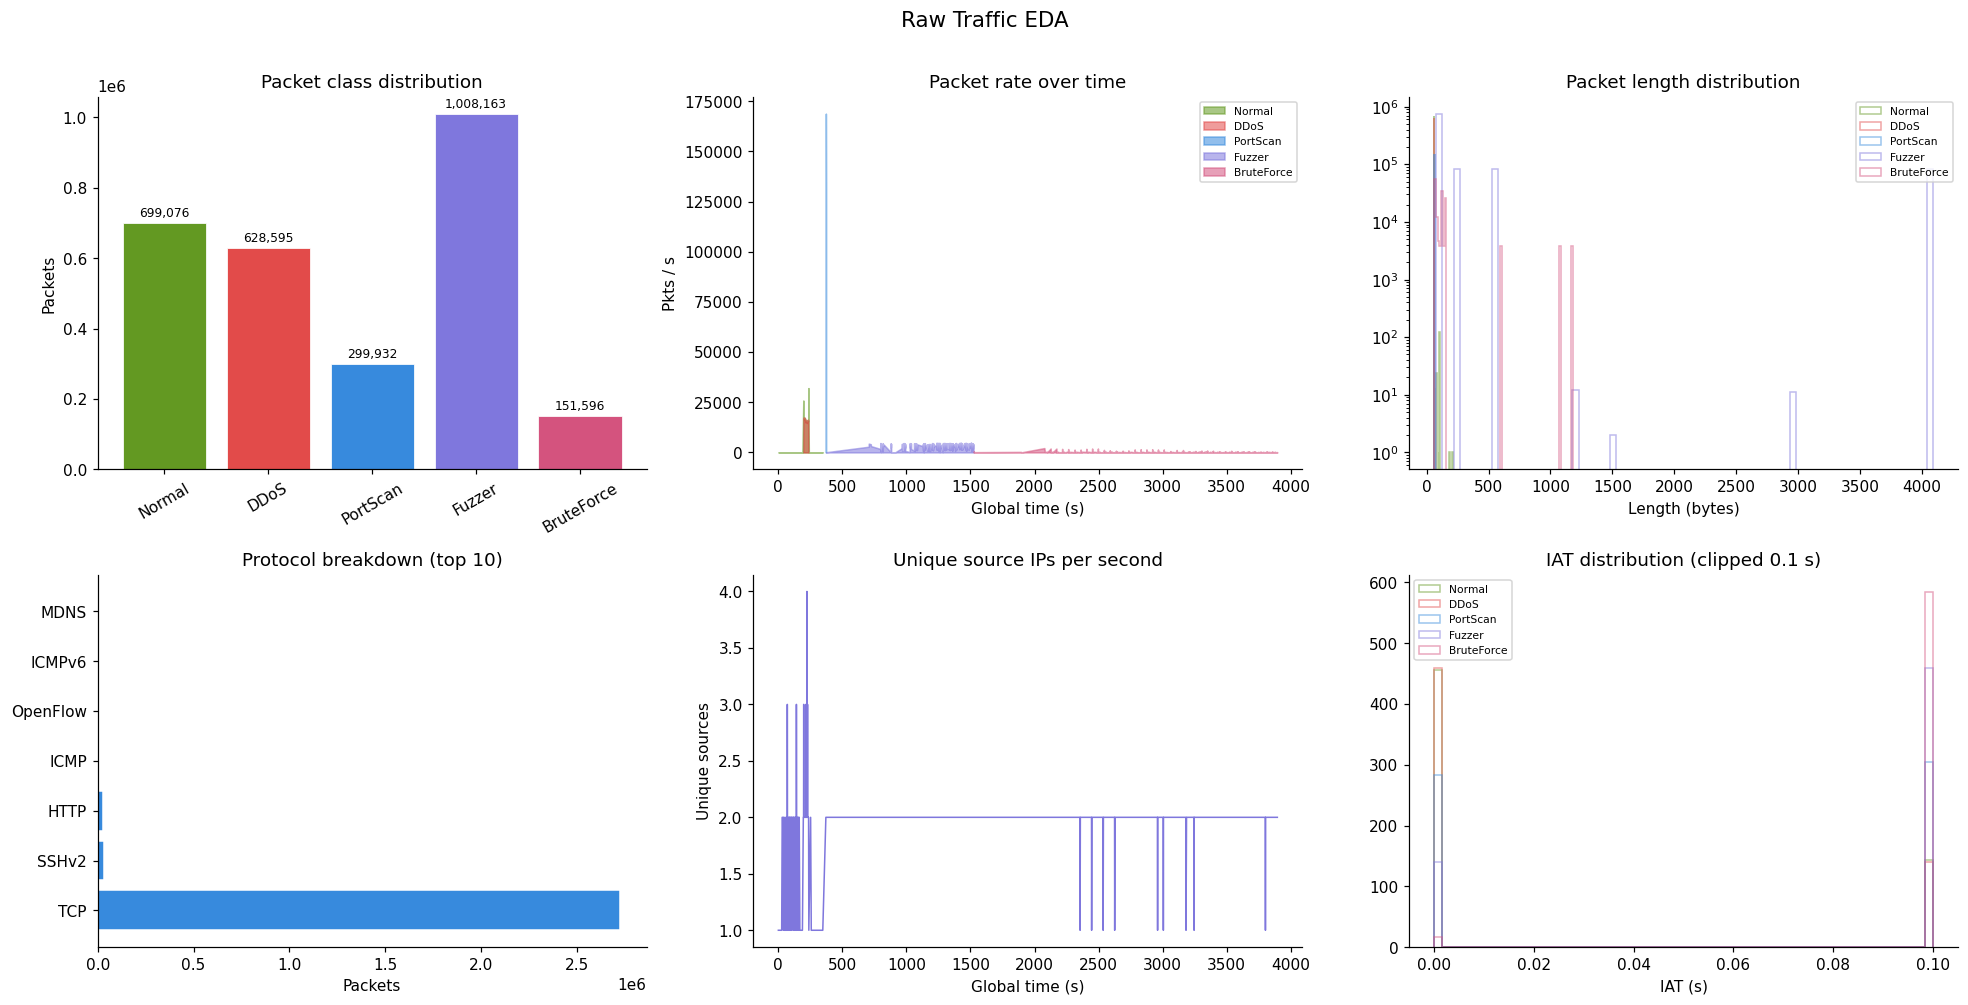

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 3a. Class distribution
ax = axes[0, 0]
counts = df_all['Label'].value_counts().sort_index()
colors = [CLASS_COLORS[k] for k in counts.index]
bars = ax.bar([CLASS_NAMES[k] for k in counts.index], counts.values,
              color=colors, edgecolor='white', lw=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            f'{v:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Packet class distribution')
ax.set_ylabel('Packets')
ax.tick_params(axis='x', rotation=30)

# 3b. Packet rate over time (global_time binned to seconds)
ax = axes[0, 1]
df_all['time_bin'] = df_all['global_time'].astype(int)
for lbl, color in CLASS_COLORS.items():
    pps = df_all[df_all['Label'] == lbl].groupby('time_bin').size()
    if len(pps):
        ax.fill_between(pps.index, pps.values, alpha=0.55,
                        color=color, label=CLASS_NAMES[lbl])
ax.set_title('Packet rate over time')
ax.set_xlabel('Global time (s)')
ax.set_ylabel('Pkts / s')
ax.legend(fontsize=7, loc='upper right')

# 3c. Packet length distribution
ax = axes[0, 2]
for lbl, color in CLASS_COLORS.items():
    data = df_all[df_all['Label'] == lbl]['Length']
    if len(data):
        ax.hist(data,
    bins=80,
    histtype='step',
    alpha=0.5,
    color=color,
    label=CLASS_NAMES[lbl])
ax.set_yscale('log')
ax.set_title('Packet length distribution')
ax.set_xlabel('Length (bytes)')
ax.legend(fontsize=7,loc='upper right')

# 3d. Protocol breakdown
ax = axes[1, 0]
proto_counts = df_all['Protocol'].value_counts().head(10)
ax.barh(proto_counts.index, proto_counts.values,
        color='#378ADD', edgecolor='white')
ax.set_title('Protocol breakdown (top 10)')
ax.set_xlabel('Packets')

# 3e. Unique source IPs per second
ax = axes[1, 1]
src_div = df_all.groupby('time_bin')['Source'].nunique()
ax.plot(src_div.index, src_div.values, color='#7F77DD', lw=1)
ax.set_title('Unique source IPs per second')
ax.set_xlabel('Global time (s)')
ax.set_ylabel('Unique sources')

# 3f. IAT distribution (raw, clipped)
ax = axes[1, 2]
df_all['IAT_raw'] = df_all['global_time'].diff().fillna(0).clip(0, 0.1)
for lbl, color in CLASS_COLORS.items():
    d = df_all[df_all['Label'] == lbl]['IAT_raw']
    if len(d):
        ax.hist(d, bins=60,histtype='step',  alpha=0.5, color=color,
                label=CLASS_NAMES[lbl], density=True)
ax.set_title('IAT distribution (clipped 0.1 s)')
ax.set_xlabel('IAT (s)')
ax.legend(fontsize=7)

plt.suptitle('Raw Traffic EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_raw.png', bbox_inches='tight')
plt.show()


## 5 — Per-Packet Feature Extraction

In [ ]:
df = df_all

# Protocol encoding
df['Protocol_num'] = df['Protocol'].astype(str).map(PROTOCOL_MAP).fillna(0).astype(np.int16)

# Port extraction — search (not match) to handle varied Info formats
ports = df['Info'].str.extract(r'(\d+)\s*>\s*(\d+)')
df['src_port'] = pd.to_numeric(ports[0], errors='coerce').fillna(-1).astype(np.int32)
df['dst_port'] = pd.to_numeric(ports[1], errors='coerce').fillna(-1).astype(np.int32)

# TCP flags
for flag in ['SYN','ACK','FIN','RST','PSH','URG']:
    df[f'flag_{flag}'] = df['Info'].str.contains(flag, regex=False).astype(np.int8)

# Drop Info and Protocol early to save huge memory
df = df.drop(columns=['Info', 'Protocol'])
import gc
gc.collect()

# Flow ID: src → dst : dst_port / proto
df['flow_id'] = (
    df['Source'].astype(str) + '->' +
    df['Destination'].astype(str) + ':' +
    df['dst_port'].astype(str) + '/' +
    df['Protocol_num'].astype(str)
)
df['flow_id'] = df['flow_id'].astype('category')

# Per-flow IAT (MUST sort by flow+time, not global time)
df = df.sort_values(['flow_id','Time']).reset_index(drop=True)
df['IAT'] = df.groupby('flow_id')['Time'].diff().fillna(0).astype(np.float32)

# Back to time order for windowing
df = df.sort_values('global_time').reset_index(drop=True)

print(f'Per-packet features extracted. Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Per-packet features extracted. Shape: (2787362, 20)
Columns: ['Time', 'Source', 'Destination', 'Length', 'Label', 'source_file', 'global_time', 'time_bin', 'IAT_raw', 'Protocol_num', 'src_port', 'dst_port', 'flag_SYN', 'flag_ACK', 'flag_FIN', 'flag_RST', 'flag_PSH', 'flag_URG', 'flow_id', 'IAT']


,Time,Source,Destination,Length,Label,source_file,global_time,time_bin,IAT_raw,Protocol_num,src_port,dst_port,flag_SYN,flag_ACK,flag_FIN,flag_RST,flag_PSH,flag_URG,flow_id,IAT
0,0.000000,127.0.0.1,127.0.0.1,80,0,DDoS-TCP,0.000000,0,0.0,6653,-1,-1,0,0,0,0,0,0,127.0.0.1->127.0.0.1:-1/6653,0.000000
1,0.000480,127.0.0.1,127.0.0.1,72,0,DDoS-TCP,0.000480,0,0.0,6,42426,6653,0,1,0,0,0,0,127.0.0.1->127.0.0.1:6653/6,0.000000
2,5.001291,127.0.0.1,127.0.0.1,72,0,DDoS-TCP,5.001291,5,0.0,6,42426,6653,0,1,0,0,0,0,127.0.0.1->127.0.0.1:6653/6,5.000811


## 6 — Flow Aggregation (Flow-ID Method)

In [ ]:
# ── Window parameters ─────────────────────────────────────────────────────
WINDOW_SIZE = 100   # packets per window
STEP_SIZE   = 10    # slide step (90% overlap)

In [ ]:
def extract_window_features(df: pd.DataFrame, window_size: int, step_size: int) -> pd.DataFrame:
    """Slide a packet-count window over sorted traffic, extract one feature vector per window."""
    n = len(df)
    records = []
    has_labels = 'Label' in df.columns          # ← ADD: check once before the loop

    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        w   = df.iloc[start:end]
        pkts = len(w)

        # ── Timing ────────────────────────────────────────────────────────
        t0, t1  = float(w['Time'].iloc[0]), float(w['Time'].iloc[-1])
        dur     = max(t1 - t0, 1e-9)
        iats    = w['IAT'].values.astype(np.float64)

        # ── Volume ────────────────────────────────────────────────────────
        lengths = w['Length'].values.astype(np.float64)

        # ── Flags ─────────────────────────────────────────────────────────
        SYN = int(w['flag_SYN'].sum())
        ACK = int(w['flag_ACK'].sum())
        FIN = int(w['flag_FIN'].sum())
        RST = int(w['flag_RST'].sum())
        PSH = int(w['flag_PSH'].sum())
        URG = int(w['flag_URG'].sum())

        # ── Label: only when columns exists (training mode) ───────────────
        if has_labels:                           # ← ADD
            vc = w['Label'].value_counts()
            dominant_label = int(vc.idxmax())
            dominant_ratio = float(vc.max() / pkts)
        else:                                    # ← ADD: inference mode
            dominant_label = -1                  # unknown
            dominant_ratio = -1.0

        # ── Protocol entropy ──────────────────────────────────────────────
        proto_vals = w['Protocol_num'].value_counts(normalize=True).values
        p_entropy  = float(-np.sum(proto_vals * np.log2(proto_vals + 1e-9)))

        records.append({
            'window_idx':       start,
            'time_start':       t0,
            'time_end':         t1,
            'pkt_count':        pkts,
            'byte_total':       float(lengths.sum()),
            'byte_mean':        float(lengths.mean()),
            'byte_std':         float(lengths.std()) if pkts > 1 else 0.0,
            'byte_min':         float(lengths.min()),
            'byte_max':         float(lengths.max()),
            'pkt_rate':         pkts / dur,
            'byte_rate':        float(lengths.sum()) / dur,
            'flow_duration':    dur,
            'IAT_mean':         float(iats.mean()),
            'IAT_std':          float(iats.std()) if pkts > 1 else 0.0,
            'IAT_min':          float(iats.min()),
            'IAT_max':          float(iats.max()),
            'IAT_total':        float(iats.sum()),
            'SYN_count':        SYN,
            'ACK_count':        ACK,
            'FIN_count':        FIN,
            'RST_count':        RST,
            'PSH_count':        PSH,
            'URG_count':        URG,
            'syn_ratio':        SYN / pkts,
            'ack_ratio':        ACK / pkts,
            'fin_ratio':        FIN / pkts,
            'rst_ratio':        RST / pkts,
            'psh_ratio':        PSH / pkts,
            'syn_no_ack':       int(SYN > 0 and ACK == 0),
            'n_unique_src':     int(w['Source'].nunique()),
            'n_unique_dst':     int(w['Destination'].nunique()),
            'n_unique_flows':   int(w['flow_id'].nunique()),
            'n_unique_dports':  int(w['dst_port'].nunique()),
            'n_unique_sports':  int(w['src_port'].nunique()),
            'protocol_entropy': p_entropy,
            'dominant_ratio':   dominant_ratio,
            'Label':            dominant_label,
        })

    return pd.DataFrame(records)

In [ ]:
print(f'Extracting windows (size={WINDOW_SIZE}, step={STEP_SIZE}) from {len(df):,} packets ...')
t0 = time.time()
features_df = extract_window_features(df, WINDOW_SIZE, STEP_SIZE)
print(f'Done in {time.time()-t0:.1f}s  →  {len(features_df):,} windows')
print()
print('Label distribution (windows):')
for k,v in features_df['Label'].value_counts().sort_index().items():
    print(f'  {CLASS_NAMES.get(int(k),k):10s}: {v:,}  ({v/len(features_df)*100:.1f}%)')
features_df.head(3)

Extracting windows (size=100, step=10) from 2,787,362 packets ...
Done in 330.1s  →  278,727 windows

Label distribution (windows):
  Normal    : 69,656  (25.0%)
  DDoS      : 63,107  (22.6%)
  PortScan  : 29,993  (10.8%)
  Fuzzer    : 100,816  (36.2%)
  BruteForce: 15,155  (5.4%)


,window_idx,time_start,time_end,pkt_count,byte_total,byte_mean,byte_std,byte_min,byte_max,pkt_rate,...,psh_ratio,syn_no_ack,n_unique_src,n_unique_dst,n_unique_flows,n_unique_dports,n_unique_sports,protocol_entropy,dominant_ratio,Label
0,0,0.000000,116.659275,100,9925.0,99.25,15.733007,72.0,209.0,0.857197,...,0.0,0,12,7,17,3,3,1.173626,1.0,0
1,10,34.932944,124.275134,100,10072.0,100.72,8.825055,72.0,104.0,1.119292,...,0.0,0,9,6,13,3,3,0.758754,1.0,0
2,20,48.504860,134.515556,100,10156.0,101.56,7.671141,72.0,104.0,1.162646,...,0.0,0,8,6,12,3,3,0.621188,1.0,0


## 7 — EDA: Flow-Level Features

In [ ]:
features_df = pd.read_csv('features_final.csv')
features_df.head(10)

,window_idx,time_start,time_end,pkt_count,byte_total,byte_mean,byte_std,byte_min,byte_max,pkt_rate,...,syn_no_ack,n_unique_src,n_unique_dst,n_unique_flows,n_unique_dports,n_unique_sports,protocol_entropy,dominant_ratio,Label,Class
0,0,0.000000,116.659275,100,9925.0,99.25,15.733007,72.0,209.0,0.857197,...,0,12,7,17,3,3,1.173626,1.0,0,Normal
1,10,34.932944,124.275134,100,10072.0,100.72,8.825055,72.0,104.0,1.119292,...,0,9,6,13,3,3,0.758754,1.0,0,Normal
2,20,48.504860,134.515556,100,10156.0,101.56,7.671141,72.0,104.0,1.162646,...,0,8,6,12,3,3,0.621188,1.0,0,Normal
3,30,65.907682,141.691302,100,10180.0,101.80,7.362065,72.0,104.0,1.319546,...,0,8,6,12,3,3,0.574214,1.0,0,Normal
4,40,73.076297,148.850878,100,10124.0,101.24,8.211114,72.0,104.0,1.319704,...,0,8,6,12,3,3,0.672905,1.0,0,Normal
5,50,82.816170,168.726884,100,10068.0,100.68,8.945256,72.0,104.0,1.163999,...,0,8,6,12,3,3,0.762399,1.0,0,Normal
6,60,90.483931,195.244347,100,9772.0,97.72,13.520414,60.0,104.0,0.954559,...,0,8,7,13,4,9,0.952942,1.0,0,Normal
7,70,97.651684,195.244956,100,9388.0,93.88,17.255306,60.0,104.0,1.024661,...,0,6,6,16,9,14,1.047800,1.0,0,Normal
8,80,105.842731,195.245306,100,8972.0,89.72,19.598000,60.0,104.0,1.118536,...,0,6,6,23,16,17,1.151959,1.0,0,Normal
9,90,111.987740,195.245706,100,8532.0,85.32,20.800423,60.0,104.0,1.201086,...,0,6,6,29,22,21,1.223524,1.0,0,Normal


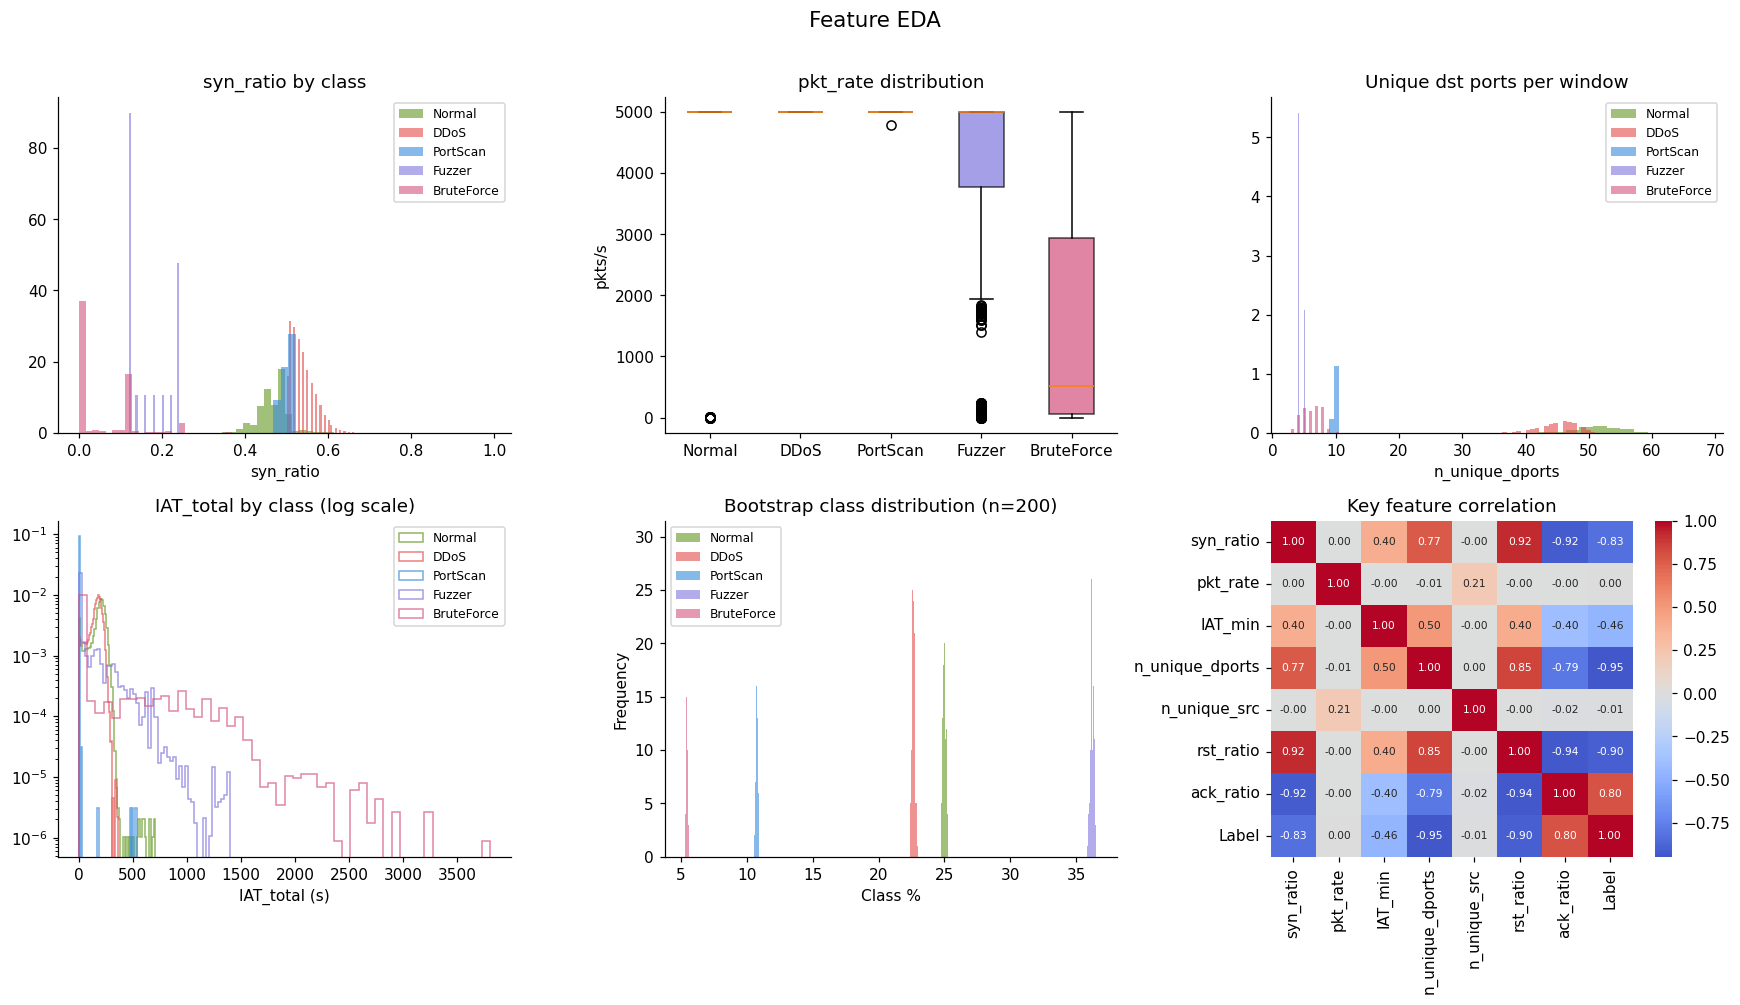

In [ ]:
FEATURE_COLS = [
    'pkt_count','byte_total','byte_mean','byte_std','byte_min','byte_max',
    'pkt_rate','byte_rate','flow_duration',
    'IAT_mean','IAT_std','IAT_min','IAT_max','IAT_total',
    'SYN_count','ACK_count','FIN_count','RST_count','PSH_count',
    'syn_ratio','ack_ratio','fin_ratio','rst_ratio','psh_ratio',
    'syn_no_ack','n_unique_src','n_unique_dst','n_unique_flows',
    'n_unique_dports','n_unique_sports','protocol_entropy'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 5a. syn_ratio by class
ax = axes[0,0]
for label, color in CLASS_COLORS.items():
    d = features_df[features_df['Label']==label]['syn_ratio']
    if len(d): ax.hist(d, bins=40, alpha=0.6, color=color, label=CLASS_NAMES[label], density=True)
ax.set_title('syn_ratio by class'); ax.set_xlabel('syn_ratio'); ax.legend(fontsize=8)

# 5b. pkt_rate by class
ax = axes[0,1]
data = [features_df[features_df['Label']==l]['pkt_rate'].clip(0,5000).values for l in range(5)]
labels = [CLASS_NAMES[l] for l in range(5)]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], CLASS_COLORS.values()):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('pkt_rate distribution'); ax.set_ylabel('pkts/s')

# 5c. n_unique_dports (port scan signal)
ax = axes[0,2]
for label, color in CLASS_COLORS.items():
    d = features_df[features_df['Label']==label]['n_unique_dports']
    if len(d): ax.hist(d, bins=30, alpha=0.6, color=color, label=CLASS_NAMES[label], density=True)
ax.set_title('Unique dst ports per window'); ax.set_xlabel('n_unique_dports'); ax.legend(fontsize=8)

# 5d. IAT_total by class (expanded range)
ax = axes[1,0]
for label, color in CLASS_COLORS.items():
    d = features_df[features_df['Label']==label]['IAT_total'].clip()
    if len(d): ax.hist(d, bins=50, histtype='step', alpha=0.7, color=color, label=CLASS_NAMES[label], density=True)
ax.set_yscale('log')
ax.set_title('IAT_total by class (log scale)'); ax.set_xlabel('IAT_total (s)'); ax.legend(fontsize=8)

# 5e. Bootstrap class distribution
ax = axes[1,1]
n_boot = 200
boot_results = []
for _ in range(n_boot):
    sample = features_df['Label'].sample(frac=0.5, replace=True)
    boot_results.append(sample.value_counts(normalize=True))
boot_df = pd.DataFrame(boot_results).fillna(0)
for label, color in CLASS_COLORS.items():
    if label in boot_df.columns:
        ax.hist(boot_df[label]*100, bins=20, alpha=0.6, color=color, label=CLASS_NAMES[label])
ax.set_title(f'Bootstrap class distribution (n={n_boot})')
ax.set_xlabel('Class %'); ax.set_ylabel('Frequency'); ax.legend(fontsize=8)

# 5f. Correlation heatmap
ax = axes[1,2]
key_feats = ['syn_ratio','pkt_rate','IAT_min','n_unique_dports','n_unique_src','rst_ratio','ack_ratio','Label']
corr = features_df[key_feats].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size':7})
ax.set_title('Key feature correlation')

plt.suptitle('Feature EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_features.png', bbox_inches='tight'); plt.show()

In [ ]:
# Quick sanity check — inspect flows per attack type
feat_cols = [
    'pkt_count', 'byte_total', 'byte_mean', 'byte_std',
    'pkt_rate', 'SYN_count', 'ACK_count', 'FIN_count', 'RST_count',
    'n_unique_dports', 'IAT_mean'
]
print('=== Window-level statistics by class ===')
for lbl in sorted(features_df['Label'].unique()):
    subset = features_df[features_df['Label'] == lbl][feat_cols]
    print(f'\n--- {CLASS_NAMES[int(lbl)]} (n={len(subset):,}) ---')
    print(subset.describe().loc[['mean','std','min','max']].round(3).to_string())

=== Window-level statistics by class ===

--- Normal (n=69,656) ---
      pkt_count  byte_total  byte_mean  byte_std      pkt_rate  SYN_count  ACK_count  FIN_count  RST_count  n_unique_dports  IAT_mean
mean      100.0    6000.654     60.007     0.004  7.212196e+06     46.589     53.396        0.0     53.395           51.595     1.750
std         0.0      46.604      0.466     0.232  8.472140e+08      3.343      3.358        0.0      3.368            3.377     0.733
min       100.0    6000.000     60.000     0.000  8.570000e-01      1.000      2.000        0.0      0.000            3.000     0.000
max       100.0   10180.000    101.800    21.036  1.000000e+11     68.000     71.000        0.0     71.000           68.000     7.058

--- DDoS (n=63,107) ---
      pkt_count  byte_total  byte_mean  byte_std   pkt_rate  SYN_count  ACK_count  FIN_count  RST_count  n_unique_dports  IAT_mean
mean      100.0    6000.031     60.000     0.003  34023.441     53.752     46.247        0.0     46.247   

## 8 — Correlation Heatmap & Mutual Information

Correlation with Label (top 10):
n_unique_dports    0.947
n_unique_flows     0.946
rst_ratio          0.905
RST_count          0.905
n_unique_sports    0.898
byte_min           0.887
psh_ratio          0.865
PSH_count          0.865
syn_ratio          0.832
SYN_count          0.832
Name: Label, dtype: float64

⚠  Leakage suspects: ['n_unique_dports', 'n_unique_flows', 'rst_ratio', 'RST_count', 'n_unique_sports', 'byte_min', 'psh_ratio', 'PSH_count']


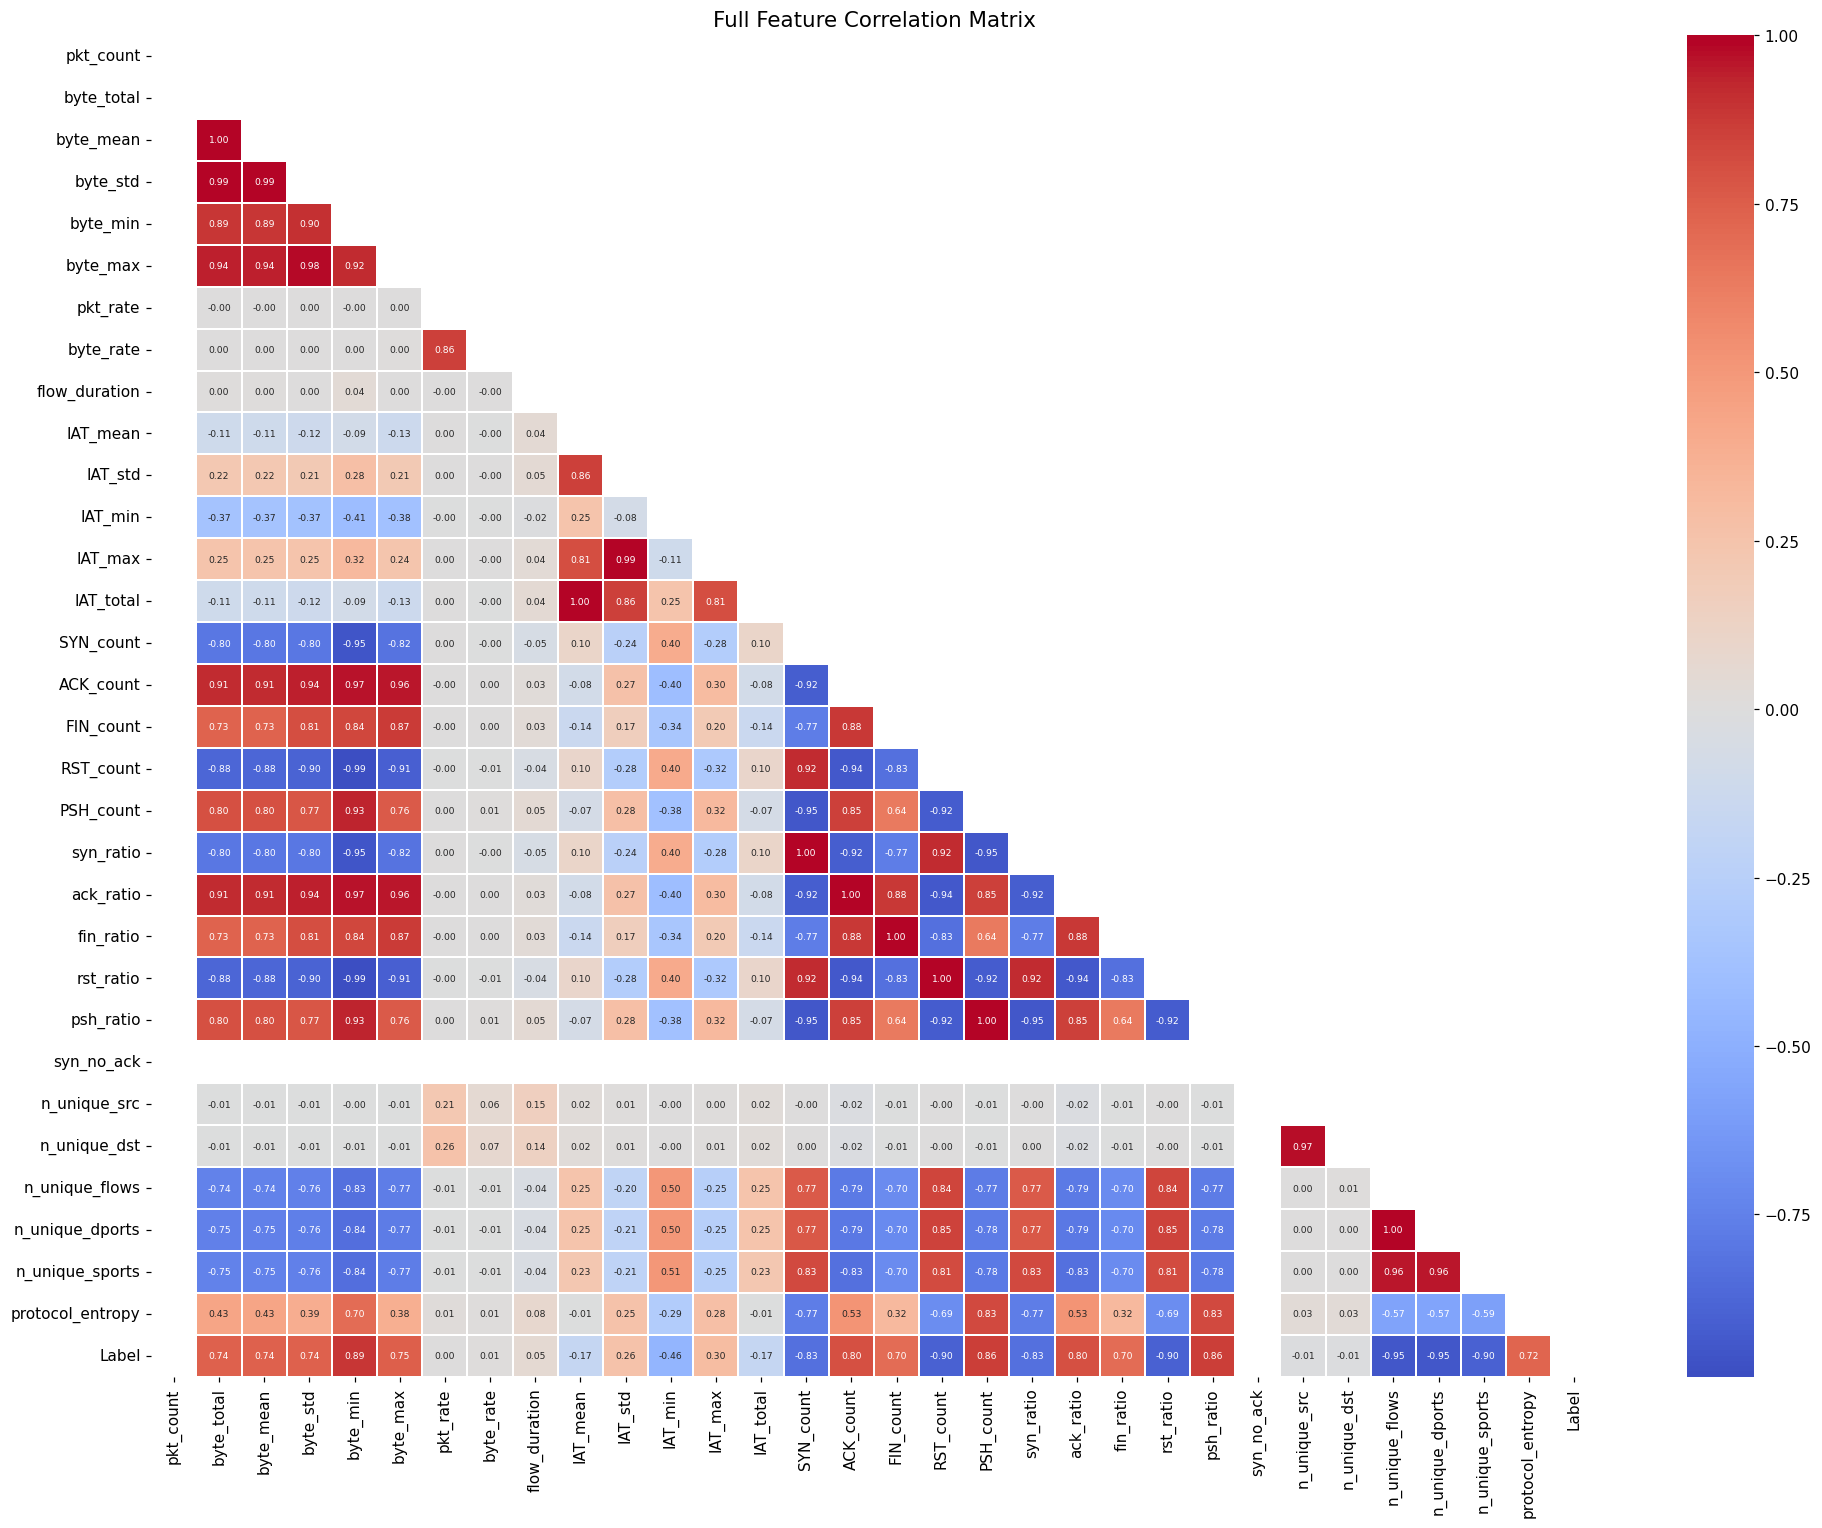

In [ ]:
fig, ax = plt.subplots(figsize=(18, 14))
corr_full = features_df[FEATURE_COLS + ['Label']].corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, ax=ax, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, annot_kws={'size':6}, linewidths=0.2)
ax.set_title('Full Feature Correlation Matrix', fontsize=14)
plt.tight_layout()

# Flag leakage suspects
label_corr = corr_full['Label'].drop('Label').abs().sort_values(ascending=False)
print('Correlation with Label (top 10):')
print(label_corr.head(10).round(3))
suspects = label_corr[label_corr > 0.85]
if len(suspects): print(f'\n⚠  Leakage suspects: {suspects.index.tolist()}')
else: print('\n✓  No leakage suspects')

In [ ]:
features_df.head(10).T

,0,1,2,3,4,5,6,7,8,9
window_idx,0,10,20,30,40,50,60,70,80,90
time_start,0.0,34.932944,48.50486,65.907682,73.076297,82.81617,90.483931,97.651684,105.842731,111.98774
time_end,116.659275,124.275134,134.515556,141.691302,148.850878,168.726884,195.244347,195.244956,195.245306,195.245706
pkt_count,100,100,100,100,100,100,100,100,100,100
byte_total,9925.0,10072.0,10156.0,10180.0,10124.0,10068.0,9772.0,9388.0,8972.0,8532.0
byte_mean,99.25,100.72,101.56,101.8,101.24,100.68,97.72,93.88,89.72,85.32
byte_std,15.733007,8.825055,7.671141,7.362065,8.211114,8.945256,13.520414,17.255306,19.598,20.800423
byte_min,72.0,72.0,72.0,72.0,72.0,72.0,60.0,60.0,60.0,60.0
byte_max,209.0,104.0,104.0,104.0,104.0,104.0,104.0,104.0,104.0,104.0
pkt_rate,0.857197,1.119292,1.162646,1.319546,1.319704,1.163999,0.954559,1.024661,1.118536,1.201086


## 9 — Train / Test Split & Preprocessing

#### The idea: do a per-class temporal split — take the last 30% of each class's rows (in their original time order) as test, then concatenate. Every class gets a temporal split, and none disappears.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler


X_all = features_df[FEATURE_COLS].fillna(0).values.astype(np.float32)
y_all = features_df['Label'].values.astype(int)

# ── Per-class temporal split ──────────────────────────────────────────────────
# For each class: sort by original order (already time-sorted from feature
# extraction), take first 70% → train, last 30% → test.
# This preserves temporal ordering within every class while guaranteeing
# all classes appear in both splits.
train_idx, test_idx = [], []

for cls in np.unique(y_all):
    idx = np.where(y_all == cls)[0]   # indices of this class, in row order
    split = int(len(idx) * 0.70)
    train_idx.extend(idx[:split])
    test_idx.extend(idx[split:])

# Sort indices to restore approximate time order across classes
train_idx = np.array(sorted(train_idx))
test_idx  = np.array(sorted(test_idx))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]



print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train label dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  label dist: {dict(zip(*np.unique(y_test,  return_counts=True)))}')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit only on train
X_test_s  = scaler.transform(X_test)

Train: 195,107  |  Test: 83,620
Train label dist: {0: 48759, 1: 44174, 2: 20995, 3: 70571, 4: 10608}
Test  label dist: {0: 20897, 1: 18933, 2: 8998, 3: 30245, 4: 4547}


## 10 — Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.preprocessing import label_binarize

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — skipping. Install with: pip install xgboost')

classes   = sorted(np.unique(y_all))
n_classes = len(classes)

MODEL_DEFS = {
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, max_depth=20,
                               class_weight='balanced', n_jobs=-1, random_state=42),
        False   # needs_scaling
    ),
    'Decision Tree': (
        DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42),
        False
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
        True
    ),
    'SVM (Linear)': (
        LinearSVC(max_iter=2000, class_weight='balanced', random_state=42),
        True
    ),
}
if HAS_XGB:
    MODEL_DEFS['XGBoost'] = (
        XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                      use_label_encoder=False, eval_metric='mlogloss',
                      random_state=42, n_jobs=-1),
        False
    )


def predict_with_proba_threshold(y_prob, threshold_normal=0.5):
    preds = np.empty(y_prob.shape[0], dtype=int)
    is_normal = y_prob[:, 0] >= threshold_normal
    preds[is_normal] = 0
    if not np.all(is_normal):
        preds[~is_normal] = np.argmax(y_prob[~is_normal, 1:], axis=1) + 1
    return preds

def predict_with_decision_bias(y_score, bias_normal=0.0):
    scores = y_score.copy()
    if scores.ndim == 1:
        scores = np.column_stack([-scores, scores])
    scores[:, 0] += bias_normal
    return np.argmax(scores, axis=1)

def train_and_evaluate(name, clf, scaled, X_tr, X_te, y_tr, y_te, X_tr_s, X_te_s):
    Xtr = X_tr_s if scaled else X_tr
    Xte = X_te_s if scaled else X_te

    from sklearn.utils.class_weight import compute_sample_weight
    fit_params = {}
    if name == 'XGBoost':
        sample_weight = compute_sample_weight(class_weight='balanced', y=y_tr)
        fit_params['sample_weight'] = sample_weight

    t0 = time.time()
    clf.fit(Xtr, y_tr, **fit_params)
    train_time = time.time() - t0

    # ROC-AUC (OvR, probability-based)
    y_te_bin = label_binarize(y_te, classes=classes)
    roc_auc = None
    best_t = 0.5
    best_bias = 0.0

    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(Xte)
        if n_classes == 2:
            roc_auc = float(roc_auc_score(y_te_bin, y_prob[:,1]))
        else:
            roc_auc = float(roc_auc_score(y_te_bin, y_prob, multi_class='ovr', average='macro'))

        best_f1 = -1.0
        for t in np.linspace(0.05, 0.95, 19):
            preds = predict_with_proba_threshold(y_prob, t)
            rep_t = classification_report(y_te, preds, output_dict=True, zero_division=0)
            f1 = rep_t['macro avg']['f1-score']
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        y_pred = predict_with_proba_threshold(y_prob, best_t)
        print(f"[{name}] Optimal threshold: {best_t:.2f} (macro F1: {best_f1:.4f})")
    elif hasattr(clf, 'decision_function'):
        y_score = clf.decision_function(Xte)
        if y_score.ndim == 1: y_score = y_score.reshape(-1,1)
        try:
            roc_auc = float(roc_auc_score(y_te_bin, y_score, multi_class='ovr', average='macro'))
        except Exception:
            roc_auc = None

        best_f1 = -1.0
        for b in np.linspace(-3.0, 3.0, 31):
            preds = predict_with_decision_bias(y_score, b)
            rep_b = classification_report(y_te, preds, output_dict=True, zero_division=0)
            f1 = rep_b['macro avg']['f1-score']
            if f1 > best_f1:
                best_f1 = f1
                best_bias = b
        y_pred = predict_with_decision_bias(y_score, best_bias)
        print(f"[{name}] Optimal bias: {best_bias:.2f} (macro F1: {best_f1:.4f})")
    else:
        y_pred = clf.predict(Xte)

    rep    = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    cm     = confusion_matrix(y_te, y_pred, labels=classes)

    fi = None
    if hasattr(clf, 'feature_importances_'):
        fi = dict(zip(FEATURE_COLS, clf.feature_importances_.tolist()))
    elif hasattr(clf, 'coef_'):
        coef = np.abs(clf.coef_)
        fi = dict(zip(FEATURE_COLS, coef.mean(axis=0).tolist()))

    return {
        'clf':        clf,
        'train_time': round(train_time, 4),
        'accuracy':   round(rep['accuracy'], 4),
        'precision':  round(rep['weighted avg']['precision'], 4),
        'recall':     round(rep['weighted avg']['recall'], 4),
        'f1':         round(rep['weighted avg']['f1-score'], 4),
        'roc_auc':    round(roc_auc, 4) if roc_auc else None,
        'cm':         cm.tolist(),
        'report':     rep,
        'fi':         fi,
        'y_pred':     y_pred.tolist(),
        'best_t':     best_t if hasattr(clf, 'predict_proba') else None,
        'best_bias':  best_bias if hasattr(clf, 'decision_function') else None,
    }


results = {}
for name, (clf, scaled) in MODEL_DEFS.items():
    print(f'Training {name} ...', end=' ')
    results[name] = train_and_evaluate(
        name, clf, scaled,
        X_train, X_test, y_train, y_test,
        X_train_s, X_test_s
    )
    r = results[name]
    auc_str = f"  ROC-AUC={r['roc_auc']}" if r['roc_auc'] else ''
    print(f"acc={r['accuracy']:.4f}  f1={r['f1']:.4f}  t={r['train_time']:.2f}s{auc_str}")


Training Random Forest ... [Random Forest] Optimal threshold: 0.35 (macro F1: 0.9647)
acc=0.9580  f1=0.9580  t=3.82s  ROC-AUC=0.9867
Training Decision Tree ... [Decision Tree] Optimal threshold: 0.25 (macro F1: 0.9645)
acc=0.9578  f1=0.9578  t=1.01s  ROC-AUC=0.9857
Training Logistic Regression ... [Logistic Regression] Optimal threshold: 0.30 (macro F1: 0.9644)
acc=0.9577  f1=0.9577  t=2.16s  ROC-AUC=0.993
Training SVM (Linear) ... [SVM (Linear)] Optimal bias: 0.20 (macro F1: 0.9620)
acc=0.9555  f1=0.9555  t=13.35s  ROC-AUC=0.9898
Training XGBoost ... [XGBoost] Optimal threshold: 0.20 (macro F1: 0.9647)
acc=0.9580  f1=0.9581  t=3.96s  ROC-AUC=0.9933


In [ ]:
# ── Ensemble Model (Voting Classifier) ───────────────────────────────────────
# Inserted after individual model training so the result automatically joins
# the `results` dict and appears in all downstream comparison/visualisation cells.
#
# Strategy: Soft-voting over the three best probability-based classifiers
#   - Random Forest  (tree-based, high recall on DDoS)
#   - XGBoost        (boosted trees, strong on imbalanced classes) — if available
#   - Logistic Regression (linear baseline, diverse signal)
# SVM (LinearSVC) is excluded because it has no predict_proba, which is required
# for soft voting.  Decision Tree is excluded because RF already covers the
# tree-based signal with much lower variance at n_estimators=100.

from sklearn.ensemble import VotingClassifier

# ── Build the constituent estimators (fresh, unfitted instances) ──────────────
rf_est  = RandomForestClassifier(n_estimators=100, max_depth=20,
                                  class_weight='balanced', n_jobs=-1, random_state=42)
dt_est  = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
lr_est  = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)

estimators = [('rf', rf_est), ('lr', lr_est), ('dt', dt_est)]

if HAS_XGB:
    xgb_est = XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                             use_label_encoder=False, eval_metric='mlogloss',
                             random_state=42, n_jobs=-1)
    estimators.append(('xgb', xgb_est))
    print('Ensemble members: Random Forest + XGBoost + Logistic Regression (soft voting)')
else:
    print('Ensemble members: Random Forest + Logistic Regression (soft voting) — XGBoost not installed')

# ── Logistic Regression needs scaled data; VotingClassifier sees one X matrix.
# We use the SCALED matrix for everyone — RF and XGBoost are scale-invariant so
# this has no negative effect on their performance.
voting_clf = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

print('Training Ensemble (Soft Voting) ...', end=' ')
t0 = time.time()
voting_clf.fit(X_train_s, y_train)   # always use scaled data (safe for all members)
train_time_ens = time.time() - t0
print(f'done in {train_time_ens:.2f}s')

# ── Evaluate using the same helper as the other models ───────────────────────
y_prob_ens  = voting_clf.predict_proba(X_test_s)
y_te_bin    = label_binarize(y_test, classes=classes)

best_t_ens = 0.5
best_f1_ens = -1.0
for t in np.linspace(0.05, 0.95, 19):
    preds_ens = predict_with_proba_threshold(y_prob_ens, t)
    rep_t = classification_report(y_test, preds_ens, output_dict=True, zero_division=0)
    f1 = rep_t['macro avg']['f1-score']
    if f1 > best_f1_ens:
        best_f1_ens = f1
        best_t_ens = t
y_pred_ens = predict_with_proba_threshold(y_prob_ens, best_t_ens)
print(f"[Ensemble] Optimal class 0 threshold: {best_t_ens:.2f} (macro F1: {best_f1_ens:.4f})")

rep_ens  = classification_report(y_test, y_pred_ens, output_dict=True, zero_division=0)
cm_ens   = confusion_matrix(y_test, y_pred_ens, labels=classes)
roc_ens  = float(roc_auc_score(y_te_bin, y_prob_ens, multi_class='ovr', average='macro'))

# Feature importance: average the RF member's importances
rf_member = voting_clf.named_estimators_['rf']
fi_ens    = dict(zip(FEATURE_COLS, rf_member.feature_importances_.tolist()))

results['Ensemble (Soft Voting)'] = {
    'clf':        voting_clf,
    'train_time': round(train_time_ens, 4),
    'accuracy':   round(rep_ens['accuracy'], 4),
    'precision':  round(rep_ens['weighted avg']['precision'], 4),
    'recall':     round(rep_ens['weighted avg']['recall'], 4),
    'f1':         round(rep_ens['weighted avg']['f1-score'], 4),
    'roc_auc':    round(roc_ens, 4),
    'cm':         cm_ens.tolist(),
    'report':     rep_ens,
    'fi':         fi_ens,
    'y_pred':     y_pred_ens.tolist(),
    'best_t':     best_t_ens,
}

r = results['Ensemble (Soft Voting)']
print(f"Ensemble → acc={r['accuracy']:.4f}  "
      f"f1={r['f1']:.4f}  "
      f"ROC-AUC={r['roc_auc']:.4f}  "
      f"t={r['train_time']:.2f}s")
print()
print('Per-class report:')
print(classification_report(y_test, y_pred_ens,
                             target_names=[CLASS_NAMES[c] for c in classes],
                             zero_division=0))


Ensemble members: Random Forest + XGBoost + Logistic Regression (soft voting)
Training Ensemble (Soft Voting) ... done in 12.57s
[Ensemble] Optimal class 0 threshold: 0.25 (macro F1: 0.9646)
Ensemble → acc=0.9580  f1=0.9580  ROC-AUC=0.9930  t=12.57s

Per-class report:
              precision    recall  f1-score   support

      Normal       0.92      0.91      0.92     20897
        DDoS       0.90      0.92      0.91     18933
    PortScan       1.00      1.00      1.00      8998
      Fuzzer       1.00      1.00      1.00     30245
  BruteForce       1.00      1.00      1.00      4547

    accuracy                           0.96     83620
   macro avg       0.96      0.96      0.96     83620
weighted avg       0.96      0.96      0.96     83620



## 11 — Model Evaluation

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
               XGBoost    0.9580     0.9582  0.9580    0.9581   0.9933          3.9579
         Random Forest    0.9580     0.9582  0.9580    0.9580   0.9867          3.8230
Ensemble (Soft Voting)    0.9580     0.9581  0.9580    0.9580   0.9930         12.5726
         Decision Tree    0.9578     0.9580  0.9578    0.9578   0.9857          1.0103
   Logistic Regression    0.9577     0.9578  0.9577    0.9577   0.9930          2.1619
          SVM (Linear)    0.9555     0.9570  0.9555    0.9555   0.9898         13.3465


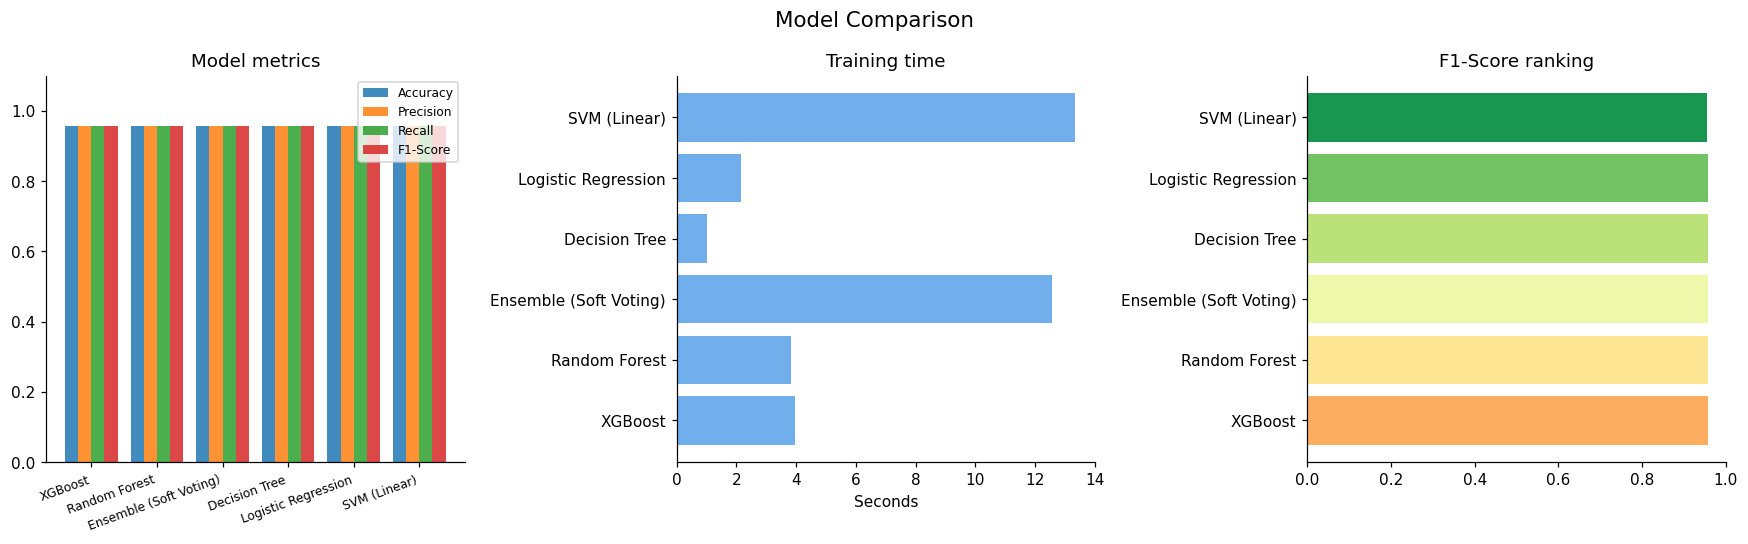

In [ ]:
# Comparison table
comparison = pd.DataFrame([
    {'Model': name, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
     'Recall': r['recall'], 'F1-Score': r['f1'],
     'ROC-AUC': r['roc_auc'] if r['roc_auc'] else 'N/A',
     'Train Time (s)': r['train_time']}
    for name, r in results.items()
])
comparison = comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Metrics bar chart
ax = axes[0]
metrics = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(comparison))
width = 0.2
for i, m in enumerate(metrics):
    vals = comparison[m].astype(float).values
    ax.bar(x + i*width, vals, width, label=m, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(comparison['Model'], rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.1); ax.set_title('Model metrics'); ax.legend(fontsize=8)

# Training time
ax = axes[1]
ax.barh(comparison['Model'], comparison['Train Time (s)'].astype(float), color='#4C9BE8', alpha=0.8)
ax.set_title('Training time'); ax.set_xlabel('Seconds')

# F1 ranking
ax = axes[2]
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comparison)))
ax.barh(comparison['Model'], comparison['F1-Score'].astype(float), color=colors_bar)
ax.set_xlim(0, 1); ax.set_title('F1-Score ranking')

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight'); plt.show()

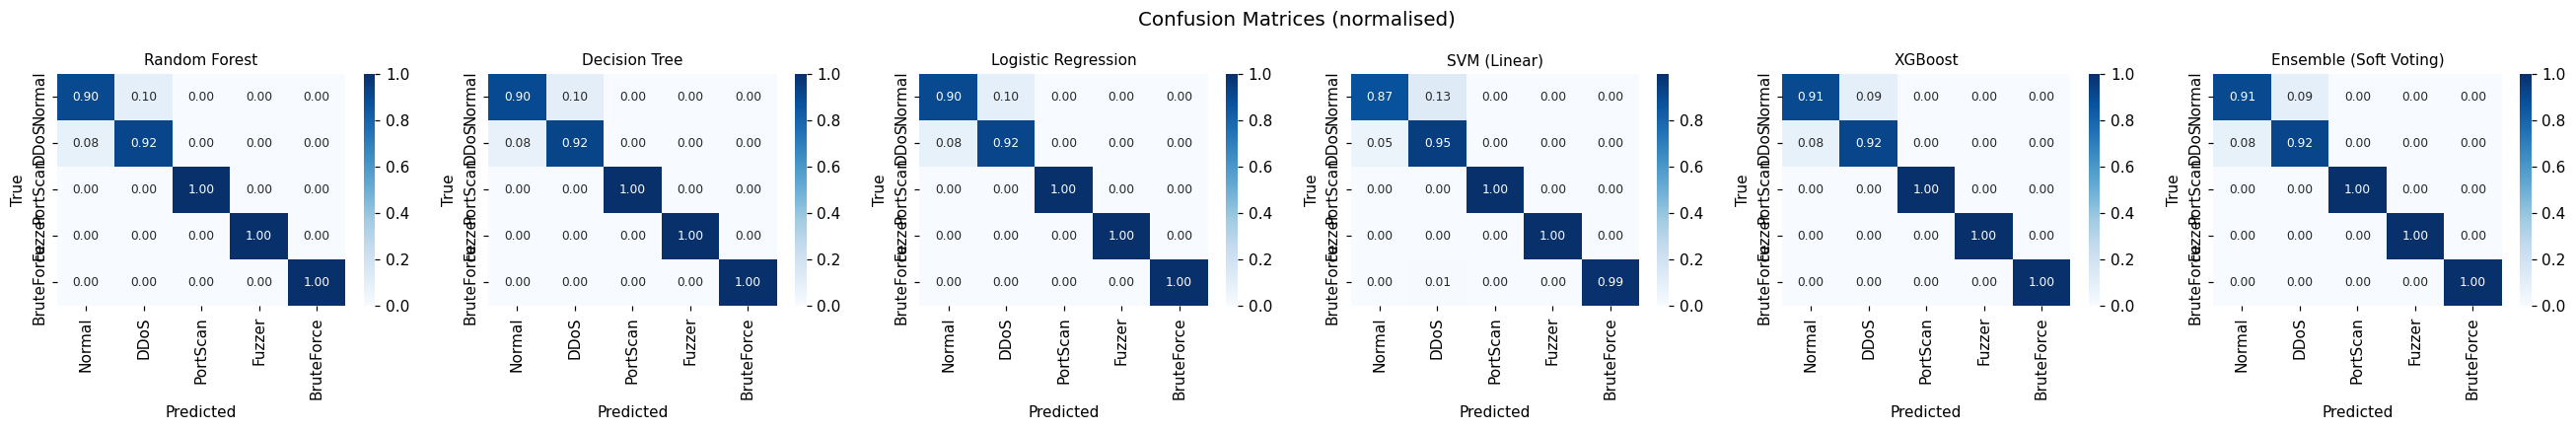

In [ ]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1: axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm = np.array(r['cm'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[CLASS_NAMES[c] for c in classes],
                yticklabels=[CLASS_NAMES[c] for c in classes],
                annot_kws={'size': 8})
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (normalised)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight'); plt.show()

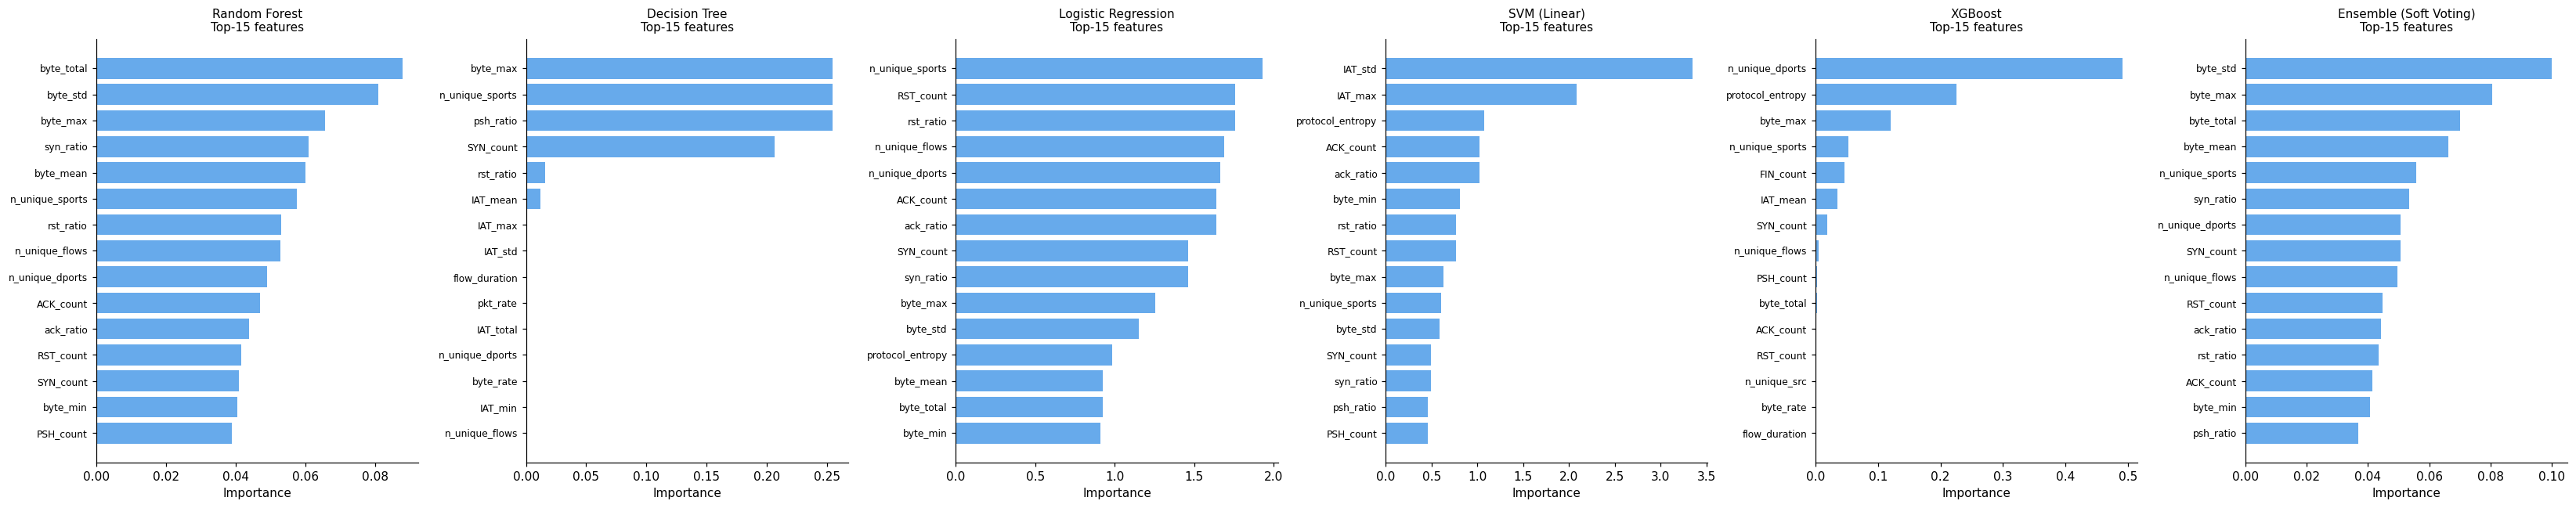

In [ ]:
fi_models = {n: r for n, r in results.items() if r['fi'] is not None}
fig, axes = plt.subplots(1, len(fi_models), figsize=(5*len(fi_models), 6))
if len(fi_models)==1: axes=[axes]

for ax, (name, r) in zip(axes, fi_models.items()):
    fi = pd.Series(r['fi']).sort_values(ascending=True).tail(15)
    ax.barh(fi.index, fi.values, color='#4C9BE8', alpha=0.85)
    ax.set_title(f'{name}\nTop-15 features', fontsize=10)
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight'); plt.show()

In [ ]:
# Best model = highest F1
best_name = comparison.iloc[0]['Model']
print(f'Best model: {best_name}  (F1={comparison.iloc[0]["F1-Score"]})')

# Save features
features_df.to_csv(OUTPUT_FEATURES, index=False)
print(f'Features saved → {OUTPUT_FEATURES}  ({len(features_df):,} rows)')

# Build serialisable results (strip non-serialisable clf objects separately)
results_meta = {
    name: {k: v for k, v in r.items() if k != 'clf'}
    for name, r in results.items()
}

bundle = {
    'models':       {name: r['clf'] for name, r in results.items()},
    'scaler':       scaler,
    'feature_cols': FEATURE_COLS,
    'class_names':  CLASS_NAMES,
    'class_colors': CLASS_COLORS,
    'results_meta': results_meta,
    'best_model':   best_name,
    'window_size':  WINDOW_SIZE,
    'step_size':    STEP_SIZE,
    'thresholds':   {name: r.get('best_t', 0.5) for name, r in results.items()},
    'biases':       {name: r.get('best_bias', 0.0) for name, r in results.items()},
}
joblib.dump(bundle, OUTPUT_BUNDLE, compress=3)
print(f'Bundle saved → {OUTPUT_BUNDLE}')
print('Done. Run: streamlit run dashboard.py')


Best model: XGBoost  (F1=0.9581)
Features saved → features_final.csv  (278,727 rows)
Bundle saved → ids_bundle.pkl
Done. Run: streamlit run dashboard.py


## 12 — Testing

In [ ]:
def _extract_per_packet_features(df):

    # Protocol encoding
    df['Protocol_num'] = df['Protocol'].astype(str).map(PROTOCOL_MAP).fillna(0).astype(np.int16)

    # Port extraction — search (not match) to handle varied Info formats
    ports = df['Info'].str.extract(r'(\d+)\s*>\s*(\d+)')
    df['src_port'] = pd.to_numeric(ports[0], errors='coerce').fillna(-1).astype(np.int32)
    df['dst_port'] = pd.to_numeric(ports[1], errors='coerce').fillna(-1).astype(np.int32)

    # TCP flags
    for flag in ['SYN','ACK','FIN','RST','PSH','URG']:
        df[f'flag_{flag}'] = df['Info'].str.contains(flag, regex=False).astype(np.int8)

    # Drop Info and Protocol early to save huge memory
    df = df.drop(columns=['Info', 'Protocol'])
    import gc
    gc.collect()

    # Flow ID: src → dst : dst_port / proto
    df['flow_id'] = (
        df['Source'].astype(str) + '->' +
        df['Destination'].astype(str) + ':' +
        df['dst_port'].astype(str) + '/' +
        df['Protocol_num'].astype(str)
    )
    df['flow_id'] = df['flow_id'].astype('category')

    # Per-flow IAT (MUST sort by flow+time, not global time)
    df = df.sort_values(['flow_id','Time']).reset_index(drop=True)
    df['IAT'] = df.groupby('flow_id')['Time'].diff().fillna(0).astype(np.float32)

    # Back to time order for windowing
    df = df.sort_values('Time').reset_index(drop=True)
    return df

In [ ]:
def predict_with_proba_threshold(y_prob, threshold_normal=0.5):
    preds = np.empty(y_prob.shape[0], dtype=int)
    is_normal = y_prob[:, 0] >= threshold_normal
    preds[is_normal] = 0
    if not np.all(is_normal):
        preds[~is_normal] = np.argmax(y_prob[~is_normal, 1:], axis=1) + 1
    return preds

def predict_with_decision_bias(y_score, bias_normal=0.0):
    scores = y_score.copy()
    if scores.ndim == 1:
        scores = np.column_stack([-scores, scores])
    scores[:, 0] += bias_normal
    return np.argmax(scores, axis=1)

def predict_csv(
    csv_path: str,
    bundle_path: str = 'ids_bundle.pkl',
    nrows: int = None,
) -> pd.DataFrame:
    """
    Full inference pipeline — mirrors the notebook end-to-end.

    Parameters
    ----------
    csv_path    : path to a Wireshark CSV export
    bundle_path : path to ids_bundle.pkl saved by the notebook
    nrows       : optional row limit (useful for quick tests)

    Returns
    -------
    DataFrame with columns:
        window_idx, time_start, time_end,
        prediction (class name), confidence,
        proba_<ClassName> (one per class)
    """
    # ── Load bundle ───────────────────────────────────────────────────────────
    bundle      = joblib.load(bundle_path)
    best_name   = bundle['best_model']
    clf         = bundle['models']['Decision Tree']
    scaler      = bundle['scaler']
    class_names = bundle['class_names']          # {0: 'Normal', 1: 'DDoS', ...}
    window_size = bundle.get('window_size', 100)
    step_size   = bundle.get('step_size',   10)
    threshold   = bundle.get('thresholds', {}).get(best_name, 0.5)
    bias        = bundle.get('biases', {}).get(best_name, 0.0)

    # Determine whether this model needs scaling (same logic as notebook)
    clf_name      = clf.__class__.__name__
    needs_scaling = any(x in clf_name for x in
                    ['Logistic', 'SVC', 'Linear', 'SGD', 'MLP', 'KNeighbors', 'Voting'])

    # ── Step 1: load & clean  (Cell 4) ───────────────────────────────────────
    df = _load_and_clean(csv_path, nrows=nrows)

    # ── Step 2: per-packet features  (Cell 15) ───────────────────────────────
    df = _extract_per_packet_features(df)

    # ── Step 3: sliding-window aggregation  (Cell 18) ────────────────────────
    features_df = extract_window_features(df, window_size, step_size)

    if features_df.empty:
        print(f'[WARN] Not enough packets for even one window '
              f'(need {window_size}, got {len(df)})')
        return pd.DataFrame()

    # ── Step 4: scale + predict  (Cells 27-28) ───────────────────────────────
    X = features_df[FEATURE_COLS].fillna(0).values.astype(np.float32)
    X_input = scaler.transform(X) if needs_scaling else X

    if hasattr(clf, 'predict_proba'):
        probas     = clf.predict_proba(X_input)          # (n_windows, n_classes)
        pred_idx   = predict_with_proba_threshold(probas, threshold)
        confidence = probas[np.arange(len(pred_idx)), pred_idx]
    else:
        scores     = clf.decision_function(X_input)
        pred_idx   = predict_with_decision_bias(scores, bias)
        confidence = probas[np.arange(len(pred_idx)), pred_idx]
        probas     = None

    # ── Build output DataFrame ────────────────────────────────────────────────
    out = features_df[['window_idx', 'time_start', 'time_end']].copy()
    out['prediction'] = [class_names.get(int(i), f'Class_{i}') for i in pred_idx]
    out['confidence'] = confidence.round(4)

    if probas is not None:
        for i, name in sorted(class_names.items()):
            if i < probas.shape[1]:
                out[f'proba_{name}'] = probas[:, i].round(4)

    return out


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  USAGE EXAMPLE
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    results = predict_csv(
        csv_path    = 'inference_dataset.csv',
        bundle_path = 'ids_results.pkl',
    )
    print(results.head(10))
    print('\nPrediction counts:')
    print(results['prediction'].value_counts())

  Original : (116009, 6)
  Cleaned  : (107657, 6)
   window_idx  time_start  time_end prediction  confidence  proba_Normal  \
0           0    0.000000  3.474072     Normal         1.0           1.0   
1          10    0.123550  3.546152     Normal         1.0           1.0   
2          20    2.402837  3.636262     Normal         1.0           1.0   
3          30    2.491040  3.739137     Normal         1.0           1.0   
4          40    2.730238  3.841874     Normal         1.0           1.0   
5          50    2.813803  3.906912     Normal         1.0           1.0   
6          60    3.054984  4.011379   PortScan         1.0           0.0   
7          70    3.138266  4.108541   PortScan         1.0           0.0   
8          80    3.299334  4.125442   PortScan         1.0           0.0   
9          90    3.378602  4.187316   PortScan         1.0           0.0   

   proba_DDoS  proba_PortScan  proba_Fuzzer  proba_BruteForce  
0         0.0             0.0           0.0      

In [ ]:
print(results['prediction'].value_counts())

prediction
PortScan      4618
Normal        4086
BruteForce    1132
Fuzzer         887
DDoS            33
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  USAGE EXAMPLE
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    results = predict_csv(
        csv_path    = 'ddos_only.csv',
        bundle_path = 'ids_results.pkl',
    )
    print(results.head(10))
    print('\nPrediction counts:')
    print(results['prediction'].value_counts())

  Original : (100000, 6)
  Cleaned  : (100000, 6)
   window_idx  time_start  time_end prediction  confidence  proba_Normal  \
0           0    0.000000  0.000199   PortScan         1.0           0.0   
1          10    0.000024  0.000221   PortScan         1.0           0.0   
2          20    0.000041  0.000243   PortScan         1.0           0.0   
3          30    0.000063  0.000259   PortScan         1.0           0.0   
4          40    0.000085  0.000281   PortScan         1.0           0.0   
5          50    0.000101  0.000303   PortScan         1.0           0.0   
6          60    0.000123  0.000319   PortScan         1.0           0.0   
7          70    0.000145  0.000341   PortScan         1.0           0.0   
8          80    0.000161  0.000363   PortScan         1.0           0.0   
9          90    0.000184  0.000379   PortScan         1.0           0.0   

   proba_DDoS  proba_PortScan  proba_Fuzzer  proba_BruteForce  
0         0.0             1.0           0.0      

In [ ]:
print(results['prediction'].value_counts())

prediction
PortScan    8247
Normal      1720
Fuzzer        24
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import joblib
import time

def predict_csv_RF(
    csv_path: str,
    bundle_path: str = 'ids_bundle.pkl',
    nrows: int = None,
) -> pd.DataFrame:
    # ── Load bundle — always use Random Forest ────────────────────────────────
    bundle      = joblib.load(bundle_path)
    clf         = bundle['models']['Random Forest']   # ← hardcoded RF
    scaler      = bundle['scaler']
    class_names = bundle['class_names']
    window_size = bundle.get('window_size', 100)
    step_size   = bundle.get('step_size',   10)
    threshold   = bundle.get('thresholds', {}).get('Random Forest', 0.5)
    # RF does not need scaling
    needs_scaling = False

    # ── Step 1: load & clean ──────────────────────────────────────────────────
    df = _load_and_clean(csv_path, nrows=nrows)

    # ── Step 2: per-packet features ───────────────────────────────────────────
    df = _extract_per_packet_features(df)

    # ── Step 3: sliding-window aggregation ───────────────────────────────────
    features_df = extract_window_features(df, window_size, step_size)

    if features_df.empty:
        print(f'[WARN] Not enough packets for even one window '
              f'(need {window_size}, got {len(df)})')
        return pd.DataFrame()

    # ── Step 4: predict ───────────────────────────────────────────────────────
    X      = features_df[FEATURE_COLS].fillna(0).values.astype(np.float32)
    probas = clf.predict_proba(X)
    pred_idx   = predict_with_proba_threshold(probas, threshold)
    confidence = probas[np.arange(len(pred_idx)), pred_idx]

    out = features_df[['window_idx', 'time_start', 'time_end']].copy()
    out['prediction'] = [class_names.get(int(i), f'Class_{i}') for i in pred_idx]
    out['confidence'] = confidence.round(4)
    for i, name in sorted(class_names.items()):
        if i < probas.shape[1]:
            out[f'proba_{name}'] = probas[:, i].round(4)

    return out


# ── Usage ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':

    TEST_CSV    = 'Port_Scanning.csv'
    BUNDLE_PATH = 'ids_bundle.pkl'

    # Limit to 1,000,000 rows so that inference completes quickly and safely
    results = predict_csv_RF(TEST_CSV, BUNDLE_PATH, nrows=1000000)
    print(results.head(10))
    print('\nPrediction counts:')
    print(results['prediction'].value_counts())


  Original : (1000000, 6)
  Cleaned  : (999852, 6)
   window_idx  time_start   time_end prediction  confidence  proba_Normal  \
0           0   13.049552  13.070305   PortScan        0.99          0.01   
1          10   13.056313  13.070457   PortScan        1.00          0.00   
2          20   13.056689  13.070563   PortScan        1.00          0.00   
3          30   13.062333  13.070706   PortScan        1.00          0.00   
4          40   13.062459  13.070770   PortScan        0.86          0.14   
5          50   13.068495  13.070870   PortScan        0.82          0.18   
6          60   13.068673  13.070924   PortScan        0.96          0.04   
7          70   13.068741  13.070974   PortScan        0.99          0.01   
8          80   13.068777  13.071014   PortScan        0.97          0.03   
9          90   13.068851  13.071309   PortScan        0.97          0.03   

   proba_DDoS  proba_PortScan  proba_Fuzzer  proba_BruteForce  
0         0.0            0.99        

In [ ]:
if __name__ == '__main__':
    results = predict_csv_RF('Brute Force ATTACK.csv', 'ids_bundle.pkl')
    print(results.head(10))
    print('\nPrediction counts:')
    print(results['prediction'].value_counts())

  Original : (151596, 6)
  Cleaned  : (151596, 6)
   window_idx  time_start  time_end  prediction  confidence  proba_Normal  \
0           0    0.000000  0.071600  BruteForce         1.0           0.0   
1          10    0.003020  0.080352  BruteForce         1.0           0.0   
2          20    0.005113  0.080382  BruteForce         1.0           0.0   
3          30    0.024638  0.081518  BruteForce         1.0           0.0   
4          40    0.025116  0.294679  BruteForce         1.0           0.0   
5          50    0.026738  0.294690  BruteForce         1.0           0.0   
6          60    0.030784  0.294728  BruteForce         1.0           0.0   
7          70    0.030995  0.294781  BruteForce         1.0           0.0   
8          80    0.071394  0.294786  BruteForce         1.0           0.0   
9          90    0.071469  0.294808  BruteForce         1.0           0.0   

   proba_DDoS  proba_PortScan  proba_Fuzzer  proba_BruteForce  
0         0.0             0.0         

In [ ]:
if __name__ == '__main__':
    results = predict_csv('inference_dataset.csv', 'ids_bundle.pkl')
    print(results.head(10))
    print('\nPrediction counts:')
    print(results['prediction'].value_counts())

  Original : (116009, 6)
  Cleaned  : (107657, 6)
   window_idx  time_start  time_end  prediction  confidence  proba_Normal  \
0           0    0.000000  3.474072      Normal      0.5829        0.5829   
1          10    0.123550  3.546152      Normal      0.5832        0.5832   
2          20    2.402837  3.636262      Normal      0.5702        0.5702   
3          30    2.491040  3.739137      Normal      0.5968        0.5968   
4          40    2.730238  3.841874      Normal      0.5968        0.5968   
5          50    2.813803  3.906912      Normal      0.5593        0.5593   
6          60    3.054984  4.011379  BruteForce      0.3743        0.2013   
7          70    3.138266  4.108541  BruteForce      0.3743        0.2013   
8          80    3.299334  4.125442  BruteForce      0.3645        0.2046   
9          90    3.378602  4.187316  BruteForce      0.3678        0.2079   

   proba_DDoS  proba_PortScan  proba_Fuzzer  proba_BruteForce  
0      0.3368          0.0334        0

In [ ]:
print(results['prediction'].value_counts())

prediction
Normal        8775
PortScan       947
Fuzzer         815
BruteForce     219
Name: count, dtype: int64
